
# Parte 5 — Teste de estresse: qualidade do detector

Escolhemos o teste de qualidade do detector: as detecções congeladas são degradadas de propósito e o rastreador roda sem retreinar, em cima do modelo final. Pergunta: o modelo temporal absorve ou amplific a falha do detector?

- **Modelo final**: o GRU da Trilha A corrigido na Parte 4 (`reports/4_memory_horizon.ipynb`; T = 32, oclusões simuladas de 8–24 quadros), seed 0, carregado do checkpoint `results/4_motion_gru_long_s0.pt` (treinado aqui se não existir).
- **Baseline**: a última caixa da Parte 1, na mesma regra de associação (Hungarian, IoU ≥ 0,3, `max_age = 20`).
- **Detecções**: SDP público, score ≥ 0,9; sequências de validação MOT17-09 e MOT17-10.

Código: `src/analysis/stress.py` (degradação e avaliação), `src/analysis/memory.py::run_tracker`, figura em `src/plot/plot.py::plot_stress`.

**Como rodar.** Localmente, com `reports/` como diretório de trabalho e `pip install -r requirements.txt`. No **Colab**: a primeira célula monta o Google Drive, lê as anotações de `Meu Drive > PA2 > Data` (a pasta `MOT17Labels` ou o zip) e procura o código do projeto em `Meu Drive > PA2` (ou num `image-detection.zip` enviado para `/content`)

In [1]:
import os, sys, glob, zipfile

IN_COLAB = "google.colab" in sys.modules
DRIVE_PA2 = "/content/drive/MyDrive/PA2"
DRIVE_DATA = os.path.join(DRIVE_PA2, "data")


def find_dir(base, marker):
    for pattern in ("", "*", os.path.join("*", "*")):
        for d in sorted(glob.glob(os.path.join(base, pattern))):
            if os.path.exists(os.path.join(d, marker)):
                return d
    return None


def find_project(base):
    return find_dir(base, os.path.join("src", "dataset", "mot17.py"))


def find_labels(base):
    return find_dir(base, os.path.join("train", "MOT17-02-FRCNN", "seqinfo.ini"))


if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # codigo
    project = find_project(DRIVE_PA2)
    if project is None and os.path.exists("/content/image-detection.zip"):
        with zipfile.ZipFile("/content/image-detection.zip") as z:
            z.extractall("/content/image-detection")
        project = find_project("/content/image-detection")
    if project is None:
        raise FileNotFoundError(f"codigo do projeto (src/) nao encontrado em {DRIVE_PA2} nem em /content/image-detection.zip")
    os.chdir(os.path.join(project, "reports"))

    # dados: o codigo espera <DATA_ROOT>/MOT17Labels/train/...
    DATA_ROOT = "/content/data"
    os.makedirs(DATA_ROOT, exist_ok=True)
    target = os.path.join(DATA_ROOT, "MOT17Labels")
    if not os.path.exists(target):
        labels = find_labels(DRIVE_DATA)
        if labels is not None:
            os.symlink(labels, target)
        else:
            zips = glob.glob(os.path.join(DRIVE_DATA, "MOT17Labels*.zip")) + \
                   glob.glob(os.path.join(DRIVE_DATA, "*", "MOT17Labels*.zip"))
            if not zips:
                raise FileNotFoundError(f"MOT17Labels (pasta ou zip) nao encontrado em {DRIVE_DATA}")
            with zipfile.ZipFile(zips[0]) as z:
                z.extractall(os.path.join(DATA_ROOT, "_labels"))
            os.symlink(find_labels(os.path.join(DATA_ROOT, "_labels")), target)
else:
    if os.path.basename(os.getcwd()) != "reports" and os.path.isdir("reports"):
        os.chdir("reports")
    DATA_ROOT = os.path.join(os.path.abspath(".."), "data")

ROOT = os.path.abspath("..")
sys.path.append(ROOT)
print("projeto:", ROOT, "| dados:", DATA_ROOT, "| MOT17Labels:", os.path.isdir(os.path.join(DATA_ROOT, "MOT17Labels")))


Mounted at /content/drive
projeto: /content/drive/MyDrive/PA2 | dados: /content/data | MOT17Labels: True


In [2]:

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.dataset.mot17 import load_sequences, SPLIT
from src.nn.train import load_or_train, CORRECTED_CONFIG
from src.analysis.memory import run_tracker
from src.analysis.stress import LEVELS, stress_test, summarize
from src.plot.plot import plot_stress

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cpu"

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
SEEDS = (0, 1, 2)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)

seqs = load_sequences(root=DATA_ROOT)
TRAIN = [seqs[n] for n in SPLIT["train"]]
VAL = [seqs[n] for n in SPLIT["val"]]

model = load_or_train(os.path.join(RESULTS_DIR, "4_motion_gru_long_s0.pt"), TRAIN, VAL, device=device, seed=0, verbose=False, **CORRECTED_CONFIG)[0]


checkpoint carregado: results/4_motion_gru_long_s0.pt


## 1. Degradação e avaliação

Sem retreinar. As detecções congeladas são estragadas em três intensidades (`src/analysis/stress.py`), 3 seeds de degradação cada:

| nível | descarte p | ruído (σ relativo ao tamanho) | falsos positivos / quadro |
|---|---|---|---|
| leve | 10 % | 0,02 | 0,5 |
| média | 20 % | 0,05 | 1,5 |
| pesada | 40 % | 0,10 | 3 |

(O SDP limpo tem ~10 detecções por quadro no MOT17-09 e ~17 no MOT17-10)

Os falsos positivos copiam tamanho e score de detecções reais da sequência (posição uniforme), então o rastreador não consegue filtrá-los pelo score. Reportamos juntos o mAP das detecções (a entrada), o mAP das trajetórias (a saída do rastreador, ele descarta e mantém caixas) e o IDF1. A coluna `amplificacao` é a queda relativa do IDF1 dividida pela queda relativa do mAP de entrada: > 1, o modelo temporal amplifica a falha do detector; < 1, **absorve**. Modelo final = o GRU corrigido (seed 0); baseline = a última caixa da Parte 1, na mesma regra de associação. Com `min_hits = 1` (a regra da Parte 1) o rastreador emite toda detecção, então o mAP das trajetórias é igual ao da entrada e todo falso positivo vira uma identidade; por isso incluímos uma terceira linha, o mesmo GRU exigindo **3 observações** antes de emitir uma track (`min_hits = 3`), é ali que o modelo temporal pode, de fato, filtrar falhas do detector que não persistem no tempo

                       mAP_det  mAP_track   IDF1  IDF1_std  IDSW_per_gt_id  id_ratio  drop_mAP_det  drop_IDF1  amplificacao
tracker                                                                                                                    
GRU            limpo     0.424      0.424  0.573     0.000           2.961     2.103         0.000      0.000           NaN
               leve      0.348      0.348  0.484     0.013           3.617     9.194         0.180      0.156         0.864
               media     0.233      0.233  0.365     0.028           5.282    21.261         0.451      0.364         0.807
               pesada    0.091      0.091  0.198     0.013          10.321    35.328         0.786      0.654         0.832
GRU min_hits=3 limpo     0.424      0.416  0.572     0.000           2.449     1.840         0.000      0.000           NaN
               leve      0.348      0.358  0.494     0.014           3.003     2.171         0.180      0.137         0.759
        

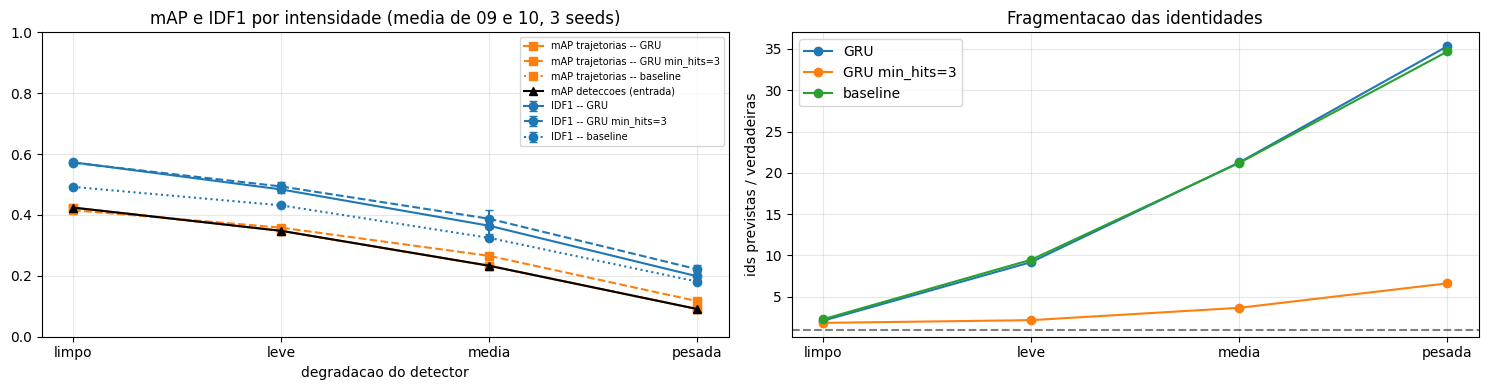

                        mAP_det                        IDF1                     
level                     limpo   leve  media pesada  limpo   leve  media pesada
sequence tracker                                                                
MOT17-09 GRU              0.444  0.356  0.225  0.081  0.583  0.523  0.371  0.196
         GRU min_hits=3   0.444  0.356  0.225  0.081  0.579  0.535  0.399  0.221
         baseline         0.444  0.356  0.225  0.081  0.483  0.451  0.323  0.182
MOT17-10 GRU              0.404  0.340  0.241  0.101  0.563  0.444  0.358  0.201
         GRU min_hits=3   0.404  0.340  0.241  0.101  0.565  0.452  0.377  0.222
         baseline         0.404  0.340  0.241  0.101  0.501  0.412  0.327  0.180


In [3]:
trackers = {
    "baseline": lambda seq, det: run_tracker(seq, None, detections=det)[0],
    "GRU": lambda seq, det: run_tracker(seq, model, detections=det)[0],
    "GRU min_hits=3": lambda seq, det: run_tracker(seq, model, detections=det, min_hits=3)[0],
}
stress = stress_test(VAL, trackers, seeds=SEEDS)
stress_summary = summarize(stress)

cols = ["mAP_det", "mAP_track", "IDF1", "IDF1_std", "IDSW_per_gt_id", "id_ratio", "drop_mAP_det", "drop_IDF1", "amplificacao"]
print(stress_summary[cols].to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_stress(stress_summary, list(LEVELS), ax=axes[0])
axes[0].set_title("mAP e IDF1 por intensidade (media de 09 e 10, 3 seeds)")
for tracker, block in stress_summary.groupby(level=0):
    block = block.droplevel(0).reindex(list(LEVELS))
    axes[1].plot(list(LEVELS), block["id_ratio"], marker="o", label=tracker)
axes[1].axhline(1, color="k", linestyle="--", alpha=0.5)
axes[1].set_ylabel("ids previstas / verdadeiras"); axes[1].set_title("Fragmentacao das identidades")
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

per_seq = stress.groupby(["sequence", "tracker", "level"])[["mAP_det", "IDF1"]].mean().unstack("level")
print(per_seq.reindex(columns=list(LEVELS), level=1).round(3).to_string())

In [4]:

results = {
    "levels": {k: {"drop": v[0], "noise": v[1], "fp_per_frame": v[2]} for k, v in LEVELS.items()},
    "seeds": list(SEEDS),
    "model": "results/4_motion_gru_long_s0.pt",
    "summary": stress_summary.reset_index().to_dict(orient="records"),
}
with open(os.path.join(RESULTS_DIR, "5_stress_test.json"), "w") as f:
    json.dump(results, f, indent=1, default=float)
stress.to_csv(os.path.join(RESULTS_DIR, "5_stress_test.csv"), index=False)
print("salvo em", RESULTS_DIR)


salvo em results


## 2. Conclusões

O `mAP_det` é idêntico entre os rastreadores em cada nível (todos recebem as mesmas detecções degradadas) e, com `min_hits = 1`, o `mAP_track` do GRU e do baseline é igual ao da entrada, como esperado: o rastreador emite toda detecção. No nível limpo `IDF1_std = 0` porque não há aleatoriedade (uma única seed). As diferenças entre rastreadores são consistentes por seed: nos 18 runs degradados (2 sequências x 3 seeds x 3 níveis) o GRU supera o baseline em 18/18 e o GRU com `min_hits = 3` supera o GRU em 18/18, inclusive no nível leve, onde o ganho médio (+0,01) é menor que o desvio entre seeds.

Absorve ou amplifica? Depende de qual parte do sistema olhamos

1. O sistema como um todo absorve a falha em IDF1. Nos três níveis o IDF1 cai proporcionalmente menos que o mAP de entrada (razão `amplificacao` entre 0,69 e 0,86, nos três rastreadores).

2. A parte aprendida é a mais frágil. A razão de amplificação do GRU é maior que a do baseline em **todos** os níveis:

   | nível | GRU | baseline | GRU `min_hits=3` |
   |---|---|---|---|
   | leve | 0,864 | 0,685 | 0,759 |
   | média | 0,807 | 0,755 | 0,715 |
   | pesada | 0,832 | 0,805 | 0,780 |

   Essa razão, porém, favorece quem já começa pior: o baseline tem IDF1 limpo menor e, portanto, menos a perder. A leitura mais justa é a vantagem do GRU sobre o baseline, que encolhe cerca de 80%:

   | nível | IDF1 GRU | IDF1 baseline | GRU − baseline |
   |---|---|---|---|
   | limpo | 0,573 | 0,492 | +0,081 |
   | leve | 0,484 | 0,432 | +0,052 |
   | média | 0,365 | 0,325 | +0,040 |
   | pesada | 0,198 | 0,181 | +0,017 |

   Descartes e ruído atacam justamente as observações de que a previsão do GRU depende; com detecções ruins, o modelo de movimento aprendido se aproxima da última caixa.

3. Na contagem de identidades, o rastreador da Parte 1 (`min_hits = 1`) amplifica: todo falso positivo vira uma identidade, e a razão ids previstas/verdadeiras vai de 2,1 para 35 (GRU) e de 2,3 para 35 (baseline). Note que já no nível limpo a razão é ~2: o rastreador fragmenta identidades mesmo sem degradação.

4. Exigir 3 observações antes de emitir uma track (`min_hits = 3`), sem retreinar, devolve a absorção: a razão de ids fica em 6,6 no nível pesado, o mAP das trajetórias passa a ficar acima do das detecções (0,266 contra 0,233 na média; 0,117 contra 0,091 na pesada), a menor queda relativa de IDF1 (0,137 / 0,322 / 0,613) e o melhor IDF1 dos três em todos os níveis degradados (0,494 / 0,388 / 0,222). No nível limpo ele custa um pouco de mAP (0,416 contra 0,424), pelos primeiros quadros de cada track que deixam de ser emitidos. Falsos positivos que não persistem no tempo são exatamente o que um modelo temporal consegue filtrar, desde que a regra de nascimento das tracks o deixe fazer isso.

**Limitações do desenho.**

- Falsos positivos fáceis de filtrar: eles têm posição uniforme e independente a cada quadro, então quase nunca persistem por 3 quadros. Falsos positivos reais (estruturas do fundo, reflexos) costumam persistir, então a recuperação do `min_hits = 3` aqui é otimista.
- Descartes independentes por detecção: perdas reais vêm em rajadas (oclusões), e com `max_age = 20` descartes isolados são fáceis de atravessar. Um teste com descartes correlacionados no tempo provavelmente penalizaria mais o GRU.
- Pouca variação estatística: são só 3 seeds de degradação e 2 sequências de validação; as conclusões se apoiam na consistência dos pares por seed, não em intervalos de confiança.